Ice_Cream Prediction Model

 Name: Jaya Bhagwant Bhute

1) Problem Statement / Objective

Problem Statement

Ice cream businesses struggle to accurately predict daily revenue due to changing temperature and weather conditions. Poor prediction leads to inefficient planning and revenue loss.


Objective

To develop a machine learning–based revenue prediction model that estimates ice cream sales revenue using features like temperature, helping improve business planning and profitability.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Conversion rate: 1 USD = 83.5 INR (adjustable if needed)
USD_TO_INR = 83.5

In [ ]:
# Step 2: Import data
# Create DataFrame from provided data
data = """Temperature,Revenue
24.6,535
26.1,626
27.8,661
20.6,488
11.6,317
14.4,368
13.8,309
30.9,697
1,56
31.7,738
11.5,326
3.7,72
18.9,468
13.7,290
39.6,906
18.5,470
26,649
42.6,922
29.6,650
21.8,535
25.5,613
15.3,354
22.7,525
16.3,375
23.9,524
19,474
15.7,403
29.2,680
19.1,518
35.2,810
24.2,529
15.3,357
8.8,238
18.3,419
35.7,810
37.1,871
22.3,551
17.6,406
31.8,741
17.1,502
23.1,540
8.8,243
18.8,422
14.2,359
18.7,468
15.7,397
21,501
30.7,652
20.5,452
31.3,698
6.4,191
27.2,622
28.7,667
28,629
10.4,220
27.4,624
33.3,750
36.6,828
12.5,304
14.4,352
16.4,382
11.6,322
33.6,775
4,132
20.6,499
6.6,196
19.9,497
11.7,285
21.5,484
18.8,431
12.7,277
27.9,628
27,644
27.4,624
24.2,587
28.8,654
40.5,919
25.6,592
28.8,652
29.5,683
16.1,373
14.8,382
22.2,516
29.1,686
29.3,655
16.4,407
27.8,644
13.4,345
29.4,643
14.4,362
30.5,705
9.1,223
23.1,544
8.6,222
12.4,338
9.1,213
20.3,475
19.4,461
14.7,344
10,284
20,469
32.1,712
14.3,323
17.7,402
26.6,628
17.3,416
23.8,554
15.6,363
28.5,644
27.8,652
25.5,604
18.5,428
24.3,566
31.7,734
17.7,386
31.9,690
26,573
29.4,720
11.1,307
25.5,597
23,541
13,342
28.3,656
30.6,703
12.6,320
19.1,451
16,383
26.2,675
31.5,732
32.3,752
21.7,497
20.5,418
19.5,449
20.2,478
6.1,159
22.9,517
24.6,600
28.6,657
19.8,508
12.5,280
36.8,842
19.7,484
32.5,740
19.3,487
19.8,457
8.7,242
29.5,619
19.3,447
24.7,604
12.5,275
24.6,532
12.3,298
12.3,320
19.8,494
23.4,587
21.2,498
18.9,477
28.3,626
16.5,391
29,676
10.3,274
11.1,281
25.5,584
28,649
28.5,727
13.4,336
26,571
32.9,686
32.8,776
32.2,774
24.8,541
15.1,367
23.5,540
35.3,810
16.4,377
20.6,478
21.4,521
27,655
22.7,519
33.3,783
9,251
26.9,635
21.4,489
22.1,521
29.2,653
16.2,384
35.4,797
11.2,294
16.6,415
30.4,692
13,340
19.9,472
21,500
23.6,543
16.6,402
30.7,681
9.9,259
31.6,716
25.5,609
25.3,575
26.9,616
21.5,534
24,579
10.5,279
5.9,187
16.2,396
24,538
9.8,229
24,604
10.1,273
22.4,494
27.4,613
20.3,438
23.2,507
15.8,410
27.6,563
18.8,403
22.7,533
18,414
13.2,333
24.9,564
18.7,473
25.9,597
26.3,597
13.4,269
21.6,529
27.2,628
27,619
38.2,851
4.3,119
9.5,279
20.2,450
19.8,449
19.2,464
19.2,475
36.2,825
23.5,554
30,697
32.1,676
29.8,696
11.2,289
23.4,507
27.8,619
15.1,368
6.4,192
14.3,335
25.5,584
24.8,539
16.4,395
18.2,474
18.6,428
32.4,748
7.6,213
31.5,692
28.4,633
17.7,449
21.8,522
18.5,438
32.5,707
17.4,406
21.1,504
23.6,571
30.8,707
22.7,544
28.9,642
9.7,275
18.6,421
5.4,146
35.5,829
24.8,595
24.7,604
28.5,652
25,608
25.5,626
22.3,536
24.8,531
22.5,536
35.1,782
33.8,798
22.6,522
28.5,608
23.5,535
26.1,600
28.9,663
22.2,513
26.4,575
25.1,551
26.5,555
22.2,497
15.6,351
17.7,410
28.8,632
27.6,662
27.2,643
10.5,322
17.6,413
24.6,539
38,858
17,426
7.8,199
5.9,171
26.9,600
24.5,559
22,551
30.1,715
21.3,527
32.5,760
17.1,442
33.4,757
23.5,543
19,455
12.3,336
25.2,576
27.1,595
25.8,622
22.4,521
25.2,588
22.2,538
28.3,640
21.8,468
15.2,375
25.4,605
18.5,464
22.9,551
14.4,316
7.3,224
25.3,564
21,490
19.8,459
42,966
28.7,690
29.3,679
15.9,380
20.9,509
30.5,685
24.9,599
19.9,417
22.2,572
34.1,772
9.6,236
25.6,580
19.1,407
23.1,537
8.1,250
29.8,703
12.2,336
35.1,808
25,565
38.2,857
19,483
18.8,437
7.3,217
12.8,296
24.6,595
39.8,936
30.3,649
24.5,597
20.3,499
20.3,476
14.9,385
28.8,634
29.8,660
26.4,610
6.8,200
23.3,556
24.4,595
25.8,573
21.7,479
26.2,564
21.7,546
18.9,445
0.3,33
19.7,507
20.2,492
24,560
29.3,698
34.9,799
11.2,279
26.2,595
39.9,876
20.5,514
17.9,441
18.4,411
10,257
25.1,584
12.1,279
37,852
14.8,323
7.2,222
38.1,820
27,645
12.5,284
10.2,277
17.6,403
12.1,301
30.5,691
7.4,193
22.7,547
28.1,666
33.6,751
24.3,570
38.7,917
0,10
24.4,573
26.2,659
5.4,243
18,442
31,703
29.8,644
32.7,819
21.2,494
18.6,444
14.6,324
41.8,970
27.2,659
20.1,478
20.6,426
27.6,650
30.3,680
21.7,506
20.1,474
17.3,406
17.2,429
35.5,801
19.2,446
19,451
26.2,618
20,542
27.8,655
21.1,522
25.4,604
24.2,589
27.6,635
8.8,247
27.6,641
16,382
17.2,391
28.8,655
17.2,413
8.8,265
31.1,685
19.3,460
27.2,616
30.1,699
45,1000
19,450
15.2,323
21.9,494
29.6,630
19.3,453
29.9,684
21.7,538
25,609
31.2,747
34.7,757
21,492
37.2,893
26.4,647
35.4,805
24.5,527
38.7,892
29,637
12.2,298
11.6,258
17.5,392
20.9,495
40.4,927
26.6,613
39.6,899
22.4,490
9.4,292
19.5,430
22.3,501
18.9,476
21.8,531
18.2,454
14.9,297
28.9,683
25.4,582
18.6,433
22.5,508
30.1,692
17,449
27.3,613
4.9,189
23.5,502
12.4,334
32.7,794
16.8,380
27,582
23.9,585
34.5,810
23.1,553
15,378
25.2,572
22.3,525
32.9,756
12.6,307
22.4,567
29,656"""

icecream = pd.DataFrame([x.split(',') for x in data.split('\n')[1:]], columns=['Temperature', 'Revenue'])

# Convert columns to appropriate types
icecream['Temperature'] = pd.to_numeric(icecream['Temperature'], errors='coerce')
icecream['Revenue'] = pd.to_numeric(icecream['Revenue'], errors='coerce')

# Drop any rows with NaN values
icecream = icecream.dropna()

# Convert revenue to INR for training (original data is assumed to be in USD)
icecream['Revenue'] = icecream['Revenue'] * USD_TO_INR


In [ ]:
# Step 3: Define target (y) and features (X)
y = icecream['Revenue']
X = icecream[['Temperature']]


In [ ]:
# Step 4: Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=2529)

In [ ]:
# Step 5: Select model
model = LinearRegression()


In [ ]:
# Step 6: Train or fit model
model.fit(X_train, y_train)

# Print model parameters (intercept and coefficient in INR)
print("Intercept (INR):", model.intercept_)
print("Coefficient (INR per °C):", model.coef_)


Intercept (INR): 3544.1385113351134
Coefficient (INR per °C): [1799.0802679]


In [ ]:
# Step 7: Predict model
y_pred = model.predict(X_test)

# Print predictions (in INR)
print("Predictions (INR):", y_pred)


Predictions (INR): [53918.38601248 31789.69871734 15058.25222588 20635.40105637
 34668.22714597 23693.83751179 31070.06661018 56077.28233396
 56437.09838754 57156.7304947  44383.26059262 51219.76561064
 30170.52647623 25313.0097529  13259.17195799 39525.7438693
 51039.85758385 51399.67363743 42764.08835151 67231.57999493
 22434.48132427 36827.12346745 36467.30741387 71909.18869146
 44383.26059262 18116.68868131 60574.98300371 26032.64186006
 42224.36427115 38986.01978893 57156.7304947  80184.9579238
 46002.43283373 51399.67363743 30710.2505566  33768.68701202
 34488.31911918 55357.6502268  73168.54487899 45462.70875336
 67771.3040753  57336.63852149 40605.19203004 26932.18199401
 53198.75390532 66691.85591456 36647.21544066 65972.2238074
 57156.7304947  41504.73216399 31789.69871734 40065.46794967
 40065.46794967 47081.88099447 55537.55825359 37906.57162819
 57516.54654828 54098.29403927 32689.23885128 55357.6502268
 42404.27229793 25852.73383327 33228.96293165 16677.42446699
 32329.42

In [ ]:
# Step 8: Model accuracy
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error (INR):", mae)
print("Mean Absolute Percentage Error:", mape)
print("Mean Squared Error (INR^2):", mse)

Mean Absolute Error (INR): 1598.0804015966069
Mean Absolute Percentage Error: 0.04221484821942015
Mean Squared Error (INR^2): 4069955.2528219675


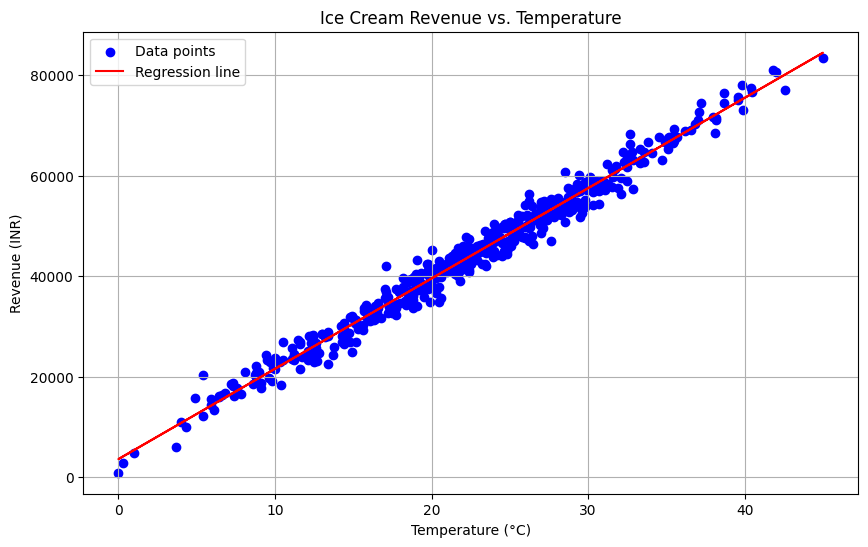

In [ ]:
# Step 9: Visualize data and regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, model.predict(X), color='red', label='Regression line')
plt.xlabel('Temperature (°C)')
plt.ylabel('Revenue (INR)')
plt.title('Ice Cream Revenue vs. Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 10: Predict revenue based on user input
def predict_revenue(temperature):
    try:
        temp = float(temperature)
        if temp < -10 or temp > 50:
            print("Please enter a realistic temperature between -10°C and 50°C.")
            return None
        revenue_usd = model.predict(np.array([[temp]]))[0]
        return round(revenue_usd, 2)
    except ValueError:
        print("Please enter a valid numeric temperature.")
        return None

# Interactive input for Google Colab
try:
    from IPython.display import display
    from ipywidgets import interact, FloatText

    @interact(temperature=FloatText(value=25.0, description='Temperature (°C):'))
    def interactive_predict(temperature):
        result = predict_revenue(temperature)
        if result is not None:
            print(f"Predicted Revenue for {temperature}°C: ₹{result}")
except ImportError:
    # Fallback for non-Colab environments
    temperature = input("Enter the temperature (°C) to predict revenue: ")
    result = predict_revenue(temperature)
    if result is not None:
        print(f"Predicted Revenue for {temperature}°C: ₹{result}")

interactive(children=(FloatText(value=25.0, description='Temperature (°C):'), Output()), _dom_classes=('widget…